## Advance Analytics and Risk Analysis


#### Historical VaR(95%) & CVaR for All 40 Schemes

In [18]:
## Calculating Daily Returns
import pandas as pd
import numpy as np
nav=pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\02_nav_history_cleaned.csv")
nav['date']=pd.to_datetime(nav['date'])
nav=nav.sort_values(['amfi_code','date'])

nav['daily_return']=(nav.groupby('amfi_code')['nav'].pct_change())

returns=nav.dropna(subset=['daily_return'])

In [19]:
## VaR and CVaR

risk_metrics=[]
for fund in returns ['amfi_code'].unique():
    rt=returns.loc[
        returns['amfi_code']==fund,'daily_return'
    ]

    var95=np.percentile(rt,5)
    cvar95=rt[rt<=var95].mean()

    risk_metrics.append([fund,var95,cvar95])

    risk_df = pd.DataFrame(
    risk_metrics,
    columns=["amfi_code","VaR95","CVaR95"]
)

risk_df.sort_values("VaR95").head()





,amfi_code,VaR95,CVaR95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595


In [20]:
risk_df.sort_values("VaR95").head(10)

,amfi_code,VaR95,CVaR95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [21]:
## Merging Fund Names
funds = pd.read_csv(r"D:\bluestock_mf_capstone\data\processed\01_fund_master_cleaned.csv")

risk_df = risk_df.merge(
    funds[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_df.to_csv(
    "D:/bluestock_mf_capstone/data/processed/var_cvar_report.csv",
    index=False
)

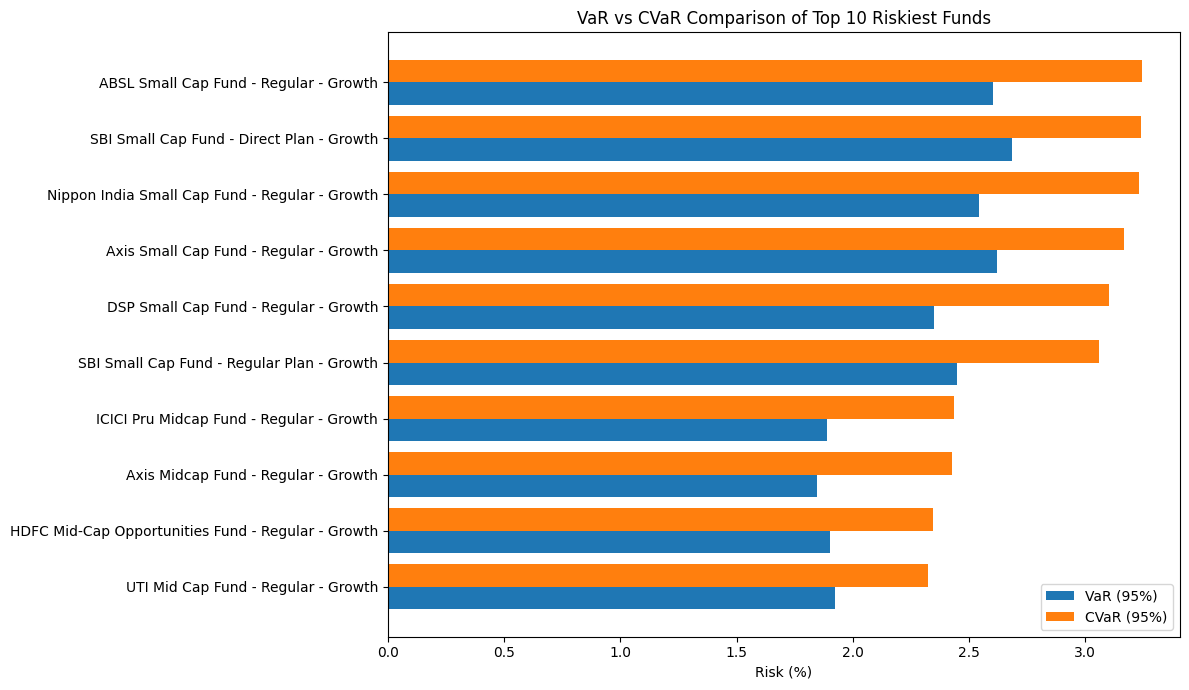

In [22]:
# Plotting Var vs CVaR chart
import matplotlib.pyplot as plt
top10 = (
    risk_df
    .sort_values('CVaR95')
    .head(10)
)

plot_df = top10.copy()

plot_df['VaR95'] = abs(plot_df['VaR95']) * 100
plot_df['CVaR95'] = abs(plot_df['CVaR95']) * 100

plot_df = plot_df.sort_values('CVaR95')

plt.figure(figsize=(12,7))

x = range(len(plot_df))

width = 0.4

plt.barh(
    [i - width/2 for i in x],
    plot_df['VaR95'],
    height=width,
    label='VaR (95%)'
)

plt.barh(
    [i + width/2 for i in x],
    plot_df['CVaR95'],
    height=width,
    label='CVaR (95%)'
)

plt.yticks(x, plot_df['scheme_name'])

plt.xlabel('Risk (%)')
plt.title('VaR vs CVaR Comparison of Top 10 Riskiest Funds')

plt.legend()

plt.tight_layout()
plt.show()


In [24]:
# Calculating Volatility Metrics
volatility_metrics = []

for fund in returns['amfi_code'].unique():

    rt = returns.loc[
        returns['amfi_code'] == fund,
        'daily_return'
    ]

    annual_vol = rt.std() * np.sqrt(252)

    volatility_metrics.append(
        [fund, annual_vol]
    )

volatility_df = pd.DataFrame(
    volatility_metrics,
    columns=['amfi_code', 'annual_volatility']
)

volatility_df.head()

# Merging Fund Names
volatility_df = volatility_df.merge(
    funds[['amfi_code','scheme_name']],
    on='amfi_code',
    how='left'
)

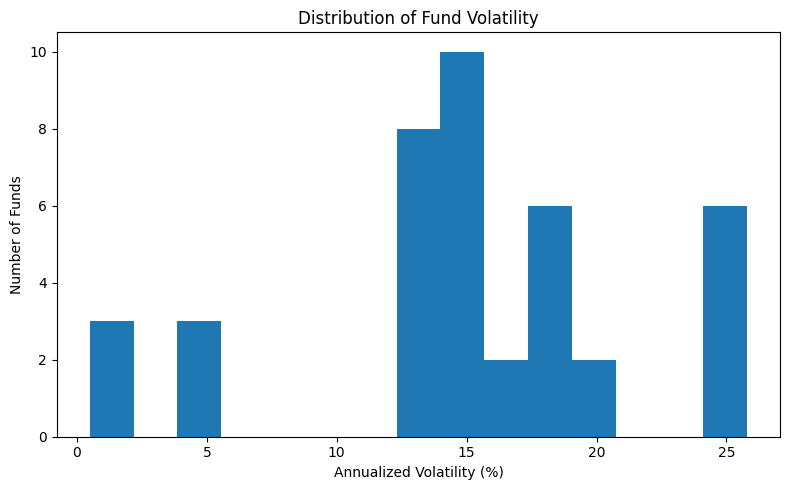

In [25]:
## Volatility Distribution Histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(
    volatility_df['annual_volatility'] * 100,
    bins=15
)

plt.xlabel('Annualized Volatility (%)')
plt.ylabel('Number of Funds')
plt.title('Distribution of Fund Volatility')

plt.tight_layout()
plt.show()

#### Rolling 90-day Sharpe


In [8]:
# Computing Sharpe
rolling_sharpe = []

for fund in returns["amfi_code"].unique():

    temp = returns[
        returns["amfi_code"] == fund
    ].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_sharpe.append(temp)

rolling_sharpe = pd.concat(rolling_sharpe)
top5 = (
    funds["amfi_code"]
    .head(5)
    .tolist()
)


In [9]:
# Selecting 5 key funds
top5 = (
    funds["amfi_code"]
    .head(5)
    .tolist()
)

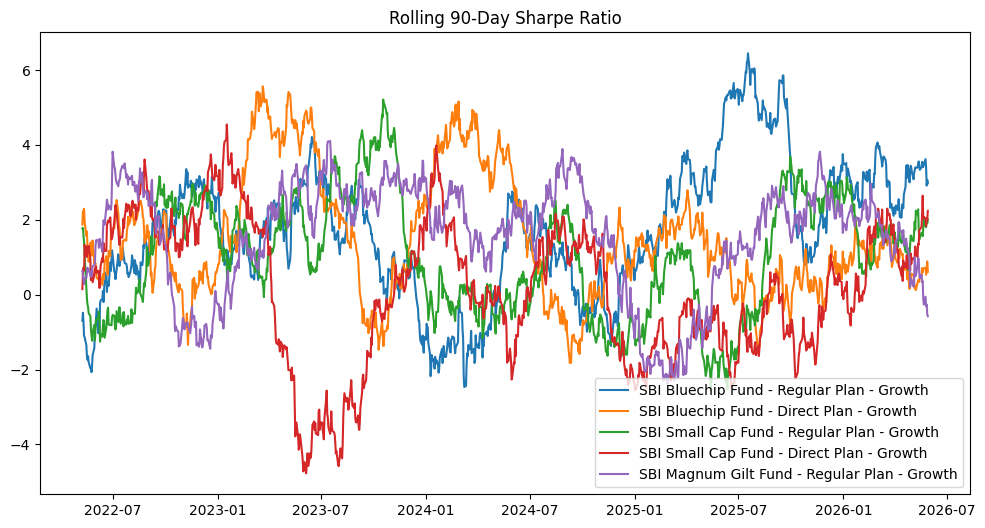

In [10]:
## Plotting the 5 key Funds

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

for fund in top5:

    temp = rolling_sharpe[
        rolling_sharpe["amfi_code"] == fund
    ]

    name = funds.loc[
        funds["amfi_code"] == fund,
        "scheme_name"
    ].iloc[0]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=name
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.legend()
plt.show()

#### Investor Cohort Analysis

In [14]:
# Creating Cohorts
txn = pd.read_csv(
    r"D:\bluestock_mf_capstone\data\processed\08_investor_transactions_cleaned.csv"
)

txn["transaction_date"] = pd.to_datetime(
    txn["transaction_date"]
)

txn["year"] = txn["transaction_date"].dt.year

In [15]:
## First Investment Year
cohort_map = (
    txn.groupby("investor_id")["year"]
       .min()
       .reset_index()
       .rename(columns={"year":"cohort_year"})
)

txn = txn.merge(
    cohort_map,
    on="investor_id"
)

## Metrics
cohort_stats = txn.groupby(
    "cohort_year"
).agg(
    avg_sip=("amount_inr","mean"),
    total_invested=("amount_inr","sum")
).reset_index()

cohort_stats

,cohort_year,avg_sip,total_invested
0,2024,107422.541832,3491125187
1,2025,109158.577061,30455243


In [20]:
## Top Fund Preference per Cohort

top_funds = (
    txn.groupby(
        ["cohort_year","amfi_code"]
    )["amount_inr"]
    .sum()
    .reset_index()
)

idx = top_funds.groupby(
    "cohort_year"
)["amount_inr"].idxmax()

cohort_top = top_funds.loc[idx]

cohort_top = cohort_top.merge(
    funds[["amfi_code","scheme_name"]],
    on="amfi_code"
)

cohort_top

,cohort_year,amfi_code,amount_inr,scheme_name
0,2024,102885,100126141,UTI Nifty 50 Index Fund - Regular - Growth
1,2025,119599,1478507,SBI Small Cap Fund - Direct Plan - Growth


#### SIP Continuity Analysis

In [21]:
## Finding Investors with 6+ SIPs
sip = txn[
    txn["transaction_type"] == "SIP"
].copy()

counts = sip.groupby(
    "investor_id"
).size()

eligible = counts[
    counts >= 6
].index

sip = sip[
    sip["investor_id"].isin(eligible)
]

In [22]:
## Finding the average gap
sip = sip.sort_values(
    ["investor_id","transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")
       ["transaction_date"]
       .diff()
       .dt.days
)   

continuity = (
    sip.groupby("investor_id")
       ["gap_days"]
       .mean()
       .reset_index()
)

continuity["status"] = np.where(
    continuity["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

continuity.head()


,investor_id,gap_days,status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [23]:
## Calculating Continuity rate
rate = (
    (continuity["status"]=="Healthy")
    .mean()
    * 100
)

print(f"SIP Continuity Rate: {rate:.2f}%")

SIP Continuity Rate: 2.20%


#### Simple fund recommender

In [25]:
# Sharpe Ratio Per Fund
sharpe = (
    returns.groupby("amfi_code")
    ["daily_return"]
    .agg(
        mean_return="mean",
        std_return="std"
    )
    .reset_index()
)

sharpe["sharpe"] = (
    sharpe["mean_return"]
    /
    sharpe["std_return"]
) * np.sqrt(252)


# Merging Risk Grade
reco_df = sharpe.merge(
    funds[
        ["amfi_code",
         "scheme_name",
         "risk_category"]
    ],
    on="amfi_code"
)

In [32]:
## Recommendation Function
def recommend_funds(risk_appetite):

    result = (
        reco_df[
            reco_df["risk_category"] == risk_appetite
        ]
        .sort_values(
            "sharpe",
            ascending=False
        )
        .head(5)
    )

    return result[
        ["scheme_name",
         "risk_category",
         "sharpe"]
    ]

recommend_funds("High")

,scheme_name,risk_category,sharpe
36,Mirae Asset Tax Saver Fund - Regular - Growth,High,1.602702
25,ICICI Pru Midcap Fund - Regular - Growth,High,1.517047
38,DSP Midcap Fund - Regular - Growth,High,1.498398
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,High,1.436947
16,Axis Midcap Fund - Regular - Growth,High,1.333160


#### Sector HHI concentration

In [28]:
## Selecting Euity Funds only
portfolio = pd.read_csv(
    r"D:\bluestock_mf_capstone\data\processed\09_portfolio_cleaned.csv"
)

equity_funds = funds.loc[
    funds["category"]
    .str.contains(
        "Equity",
        case=False,
        na=False
    ),
    "amfi_code"
]

portfolio = portfolio[
    portfolio["amfi_code"]
    .isin(equity_funds)
]

In [33]:
## Calculating HHI
hhi = (
    portfolio.groupby(
        ["amfi_code","sector"]
    )["weight_pct"]
    .sum()
    .reset_index()
)

hhi["share"] = (
    hhi["weight_pct"] / 100
)

hhi_result = (
    hhi.groupby("amfi_code")
    ["share"]
    .apply(
        lambda x: np.sum(x**2)
    )
    .reset_index(name="HHI")
)

hhi_result = hhi_result.merge(
    funds[["amfi_code","scheme_name"]],
    on="amfi_code"
)

hhi_result.sort_values(
    "HHI",
    ascending=True
).head()

,amfi_code,HHI,scheme_name
5,102886,0.124020,UTI Mid Cap Fund - Regular - Growth
25,120843,0.136206,Kotak Flexicap Fund - Regular - Growth
15,119551,0.142491,SBI Bluechip Fund - Regular Plan - Growth
14,119095,0.159582,Axis Small Cap Fund - Regular - Growth
9,118634,0.160299,Nippon India Small Cap Fund - Regular - Growth


## Insight 1
#### Risk Insight
The fund with the highest downside risk is SBI Small Cap Fund - Direct Plan - Growth, showing a Historical VaR (95%) of -0.026859 and CVaR of -0.032384, indicating larger potential losses during adverse market conditions.

## Insight 2
#### Risk-Adjusted Performance

 Mirae Asset Tax Saver Fund - Regular - Growth achieved the highest Sharpe Ratio among all schemes, delivering the strongest risk-adjusted returns over the analysis period.

## Insight 3 
#### Investor Cohort Behaviour

Investors who entered in 2025 contributed the highest average investment amount, suggesting stronger participation from recent cohorts.

## Insight 4
#### SIP Continuity

The overall SIP continuity rate is 2.20%, meaning most investors maintain regular contributions. Investors with average gaps above 35 days were classified as at-risk.

## Insight 5 
#### Portfolio Concentration
Axis Bluechip Fund - Regular - Growth exhibits the highest HHI score, indicating a highly concentrated sector allocation, while UTI Mid Cap Fund - Regular - Growth is the most diversified among equity funds.